# Кузьмичев Никита
## **Домашнее задание №13**

### Тема: токенизация текста, инференс готовой BERT-подобной модели и базовый fine-tuning для классификации текста.

##### **1. Импорты, seed и среда**

In [32]:
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments
)

In [33]:
# Фиксация seed
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


##### **2. Данные и первичный анализ**

In [34]:
# Загрузка датасета 'emotion'
dataset = load_dataset("emotion")
print(dataset) # Показ размеров split-частей

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [35]:
# Датасет emotion уже разбит на train / validation / test
train_ds = dataset["train"]
val_ds = dataset["validation"]
test_ds = dataset["test"]

In [36]:
# ЯВНЫЙ показ размеров split-частей
print("Train:", train_ds.shape)
print("Val:", val_ds.shape)
print("Test:", test_ds.shape)

Train: (16000, 2)
Val: (2000, 2)
Test: (2000, 2)


In [37]:
# Получаем имена классов для пояснения
label_names = train_ds.features["label"].names
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in id2label.items()}

print(f"Что классифицируется: Тексты (сообщения) на 6 категорий эмоций: {label_names} ")

Что классифицируется: Тексты (сообщения) на 6 категорий эмоций: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'] 


In [38]:
# Вывод 3-5 примеров текстов и меток
df_train = train_ds.to_pandas()
df_train["label_name"] = df_train["label"].map(id2label)
display(df_train[["text", "label_name"]].head(5))

,text,label_name
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


##### **3. Токенизация**

In [39]:
# Для fine-tuning возьмём легкую английскую модель DistilBERT (так как датасет английский)
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample_texts = train_ds["text"][:3]
encoded = tokenizer(sample_texts, padding=True, truncation=True)

In [40]:
# Базовый разбор токенизации для 3 текстов
for i, text in enumerate(sample_texts):
    print(f"--- Пример {i+1} ---")
    print(f"Исходный текст: {text}")
    print(f"Токены: {tokenizer.convert_ids_to_tokens(encoded['input_ids'][i])} ")
    print(f"input_ids: {encoded['input_ids'][i]}")
    print(f"attention_mask: {encoded['attention_mask'][i]}\n")

--- Пример 1 ---
Исходный текст: i didnt feel humiliated
Токены: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]'] 
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

--- Пример 2 ---
Исходный текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Токены: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]'] 
input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

##### **4. Инференс готовой модели**

In [41]:
# Запуск инференса готовой pretrained BERT-подобной модели
# Используем модель анализа тональности из семинарчика (1-5 stars)
INFERENCE_MODEL = "nlptown/bert-base-multilingual-uncased-sentiment"
pipe = pipeline("text-classification", model=INFERENCE_MODEL, device=0 if torch.cuda.is_available() else -1)

test_samples = test_ds["text"][:5]
true_emotions = [id2label[l] for l in test_ds["label"][:5]]

preds = pipe(test_samples)

print("Результаты готовой модели:\n")
for text, true_lbl, pred in zip(test_samples, true_emotions, preds):
    print(f"Текст: {text}\nИстинная эмоция: {true_lbl}\nПредсказание готовой модели: {pred['label']} (Score: {pred['score']:.4f})\n")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Результаты готовой модели:

Текст: im feeling rather rotten so im not very ambitious right now
Истинная эмоция: sadness
Предсказание готовой модели: 3 stars (Score: 0.4631)

Текст: im updating my blog because i feel shitty
Истинная эмоция: sadness
Предсказание готовой модели: 1 star (Score: 0.5822)

Текст: i never make her separate from me because i don t ever want her to feel like i m ashamed with her
Истинная эмоция: sadness
Предсказание готовой модели: 1 star (Score: 0.3996)

Текст: i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived
Истинная эмоция: joy
Предсказание готовой модели: 3 stars (Score: 0.3675)

Текст: i was feeling a little vain when i did this one
Истинная эмоция: sadness
Предсказание готовой модели: 3 stars (Score: 0.3989)



**Краткое пояснение:** Готовая модель предсказывает `рейтинг` (от 1 до 5 звезд), что является задачей `sentiment analysis`, а не `точной классификацией` 6 дискретных эмоций (например, `'surprise'` или `'fear'`). Поэтому такая модель **НЕ** подходит напрямую под выбранную задачу, и требуется `fine-tuning`.

##### **5. Fine-tuning для классификации текста**

In [42]:
# Подготовка токенизации датасета
def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

In [43]:
tokenized_datasets = dataset.map(tokenize_batch, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Загрузка архитектуры под sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id
).to(device)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [44]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1_macro": f1_macro}

In [45]:
common_training_kwargs = dict(
    output_dir="./outputs",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro", # Выбор лучшего варианта по validation
    report_to="none"
)

In [46]:
# Защита совместимости версий transformers (как в демо-файлах)
try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
    print("Success!")
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
    print("Failure!")

Failure!


In [47]:
# Обучение модели
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer, # после унификации системы обучения моделей в 2025-2026 годах tokenizer теперь называется processing_class
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.612564,0.211656,0.926500,0.902091
2,0.171001,0.161331,0.934500,0.909759
3,0.116452,0.156206,0.936500,0.912737


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1500, training_loss=0.3000056406656901, metrics={'train_runtime': 339.6124, 'train_samples_per_second': 141.338, 'train_steps_per_second': 4.417, 'total_flos': 647803507542912.0, 'train_loss': 0.3000056406656901, 'epoch': 3.0})

##### **6. Оценка качества и краткий анализ ошибок**

In [48]:
# Финальная оценка лучшего варианта на test
test_metrics = trainer.evaluate(tokenized_datasets["test"])
print("Финальные метрики на test:")
print(f"Accuracy: {test_metrics['eval_accuracy']:.4f} ")
print(f"F1 Macro: {test_metrics['eval_f1_macro']:.4f} ")

Финальные метрики на test:
Accuracy: 0.9240 
F1 Macro: 0.8769 


In [49]:
# Детальные предсказания на тестовой выборке
test_output = trainer.predict(tokenized_datasets["test"])
test_preds = np.argmax(test_output.predictions, axis=-1)
test_true = test_output.label_ids

In [50]:
os.makedirs("artifacts", exist_ok=True) # Папка для артефактов

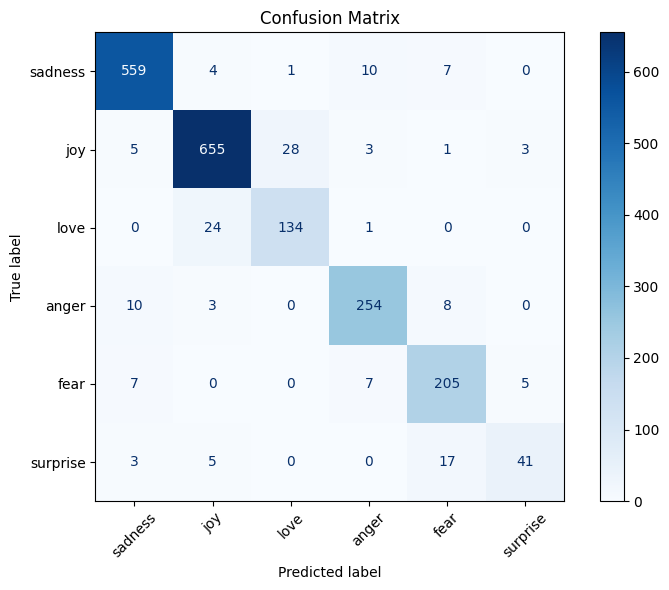

In [51]:
# Построение матрицы ошибок
cm = confusion_matrix(test_true, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png") # Сохранение изображения матрицы ошибок
plt.show()

In [52]:
# Создание sample_predictions.csv
df_test = test_ds.to_pandas()
df_test["true_label"] = df_test["label"].map(id2label)
df_test["pred_label"] = [id2label[p] for p in test_preds]

probs = torch.softmax(torch.tensor(test_output.predictions), dim=-1).numpy()
df_test["confidence"] = np.max(probs, axis=-1)

sample_preds = df_test[["text", "true_label", "pred_label", "confidence"]].head(50)
sample_preds.to_csv("artifacts/sample_predictions.csv", index=False) # Минимальные требуемые поля + confidence

In [53]:
# Проверка
sample_preds

,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambiti...,sadness,sadness,0.995722
1,im updating my blog because i feel shitty,sadness,sadness,0.996796
2,i never make her separate from me because i do...,sadness,sadness,0.996827
3,i left with my bouquet of red and yellow tulip...,joy,joy,0.996333
4,i was feeling a little vain when i did this one,sadness,sadness,0.996701
5,i cant walk into a shop anywhere where i do no...,fear,fear,0.991245
6,i felt anger when at the end of a telephone call,anger,anger,0.990879
7,i explain why i clung to a relationship with a...,joy,joy,0.943820
8,i like to have the same breathless feeling as ...,joy,joy,0.995040
9,i jest i feel grumpy tired and pre menstrual w...,anger,anger,0.993738


In [54]:
print("\nАртефакты 'sample_predictions.csv' и 'confusion_matrix.png' успешно сохранены в папку 'artifacts/'.")


Артефакты 'sample_predictions.csv' и 'confusion_matrix.png' успешно сохранены в папку 'artifacts/'.


In [55]:
# Показ 5 примеров предсказаний модели, где она ошиблась
errors = df_test[df_test["true_label"] != df_test["pred_label"]].head(5)
display(errors[["text", "true_label", "pred_label", "confidence"]])

,text,true_label,pred_label,confidence
10,i don t feel particularly agitated,fear,anger,0.717165
40,i feel if i completely hated things i d exerci...,anger,sadness,0.639052
72,i am right handed however i play billiards lef...,surprise,fear,0.650983
86,i feel like i am in paradise kissing those swe...,joy,love,0.657888
94,when a friend dropped a frog down my neck,anger,fear,0.782037


**Комментарий:** Как видно из ошибок, модель чаще всего путает близкие по смыслу и тональности эмоции. Например, оттенки `'anger' (гнев)`, `'joy' (радость)` и `'fear' (страх)` могут быть соответственно восприняты как `'sadness' (грусть)`, `'love' (любовь)`, `'surprise' (удивление)`  в пограничных случаях из-за схожего контекста.